# csp_workflow_mp — visualise benchmark predictions

Diagnostic figures for the raw output written by `scripts/05_run_benchmark.py`:

1. Per-stage success rate for each retrieval strategy (substitution → relaxation → SG match).
2. RMSD distribution on the ordered subset.
3. Space-group match rate stratified by the number of constituent elements.
4. Volume-change distribution before / after MatterSim relaxation.

The notebook reads whatever strategies are present in `results/benchmark_raw.csv`. A default run of `05_run_benchmark.py` produces `unconstrained` + `sg_only`; passing `--k 1 --k 3 --k 10` in separate runs adds the corresponding rows to the same CSV. Set `CSP_RESULTS_DIR` if the raw CSV lives outside `results/`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Canonical results directory (respects CSP_RESULTS_DIR)
from csp_workflow_mp._paths import RESULTS_DIR

raw_csv = RESULTS_DIR / 'benchmark_raw.csv'
df = pd.read_csv(raw_csv)
strategies = sorted(df['strategy'].unique())
print(f'{len(df)} rows  |  strategies: {strategies}')
df.head()

2000 rows  |  strategies: ['sg_only_k1', 'sg_only_k10', 'sg_only_k3', 'unconstrained']


,sample_idx,material_id,formula,n_elements,true_sg,strategy,template_id,template_rank,sub_success,sub_method,relax_converged,vol_change,vol_filtered,sg_match,sm_match,rmsd_angstrom,relax_sec,rmsd_angstrom_legacy_avg_a
0,0,mp-1226927,CeN2,2,8,unconstrained,mp-864757,24,True,one_to_one,True,0.1412,False,False,False,NaN,1.8,NaN
1,1,mp-1187000,Sm2GaAg,3,225,unconstrained,mp-1100765,2,True,one_to_one,True,0.0000,False,True,True,8.233658e-16,0.1,1.467071e-15
2,2,mp-1080150,Mo3W(Se3S)2,4,156,unconstrained,mp-1027109,0,True,multi_element,True,0.0000,False,True,False,NaN,0.8,NaN
3,3,mp-2714719,Na3YHf3Si3(SO8)3,6,1,unconstrained,mp-2714666,21,True,multi_element,True,0.0732,False,True,False,NaN,34.7,NaN
4,4,mp-1184603,Ho2GaOs,3,225,unconstrained,mp-865339,3,True,one_to_one,True,0.0457,False,True,True,2.573053e-06,0.2,4.584659e-06


## 1. Substitution and SG-match rates per strategy

Two paper Table 2 canonical metrics per retrieval strategy, using the same denominators as the manuscript:

- **Substitution success rate** — fraction of the 500 sampled targets where the substitution engine produced a feasible mapping (denominator: `n_total`).
- **SG match on the valid subset** — fraction of the valid-subset predictions whose relaxed space group matches the reference (denominator: `n_valid`; valid subset = `sub_success ∧ relax_converged ∧ |ΔV/V| < 15%`).

In [2]:
# Paper Table 2 canonical view: sub_success over all 500 targets (n_total);
# SG match on the valid subset (sub_success ∧ relax_converged ∧ |ΔV/V| < 15%).
valid = df[df['sub_success'] & df['relax_converged'] & (df['vol_change'] < 0.15)]

summary = pd.DataFrame({
    'n_total':                df.groupby('strategy').size(),
    'sub_success (%)':       (df.groupby('strategy')['sub_success'].mean() * 100).round(1),
    'n_valid':                valid.groupby('strategy').size(),
    'SG match on valid (%)': (valid.groupby('strategy')['sg_match'].mean() * 100).round(1),
})
summary

,n_total,sub_success (%),n_valid,SG match on valid (%)
strategy,,,,
sg_only_k1,500,81.4,322,63.0
sg_only_k10,500,86.6,350,43.1
sg_only_k3,500,86.4,347,49.6
unconstrained,500,85.2,354,40.1


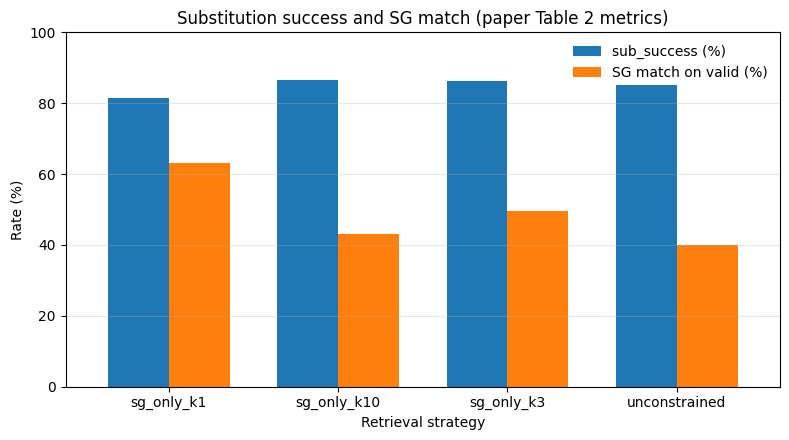

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
summary[['sub_success (%)', 'SG match on valid (%)']].plot(kind='bar', ax=ax, width=0.72)
ax.set_ylabel('Rate (%)')
ax.set_xlabel('Retrieval strategy')
ax.set_title('Substitution success and SG match (paper Table 2 metrics)')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. RMSD distribution on the ordered subset

RMSD is `pymatgen.analysis.structure_matcher.StructureMatcher.get_rms_dist`, computed only for samples where substitution succeeded, relaxation converged, and the ordered predictions could be aligned against the ordered reference.

In [4]:
rmsd_df = df.dropna(subset=['rmsd_angstrom'])
rmsd_df.groupby('strategy')['rmsd_angstrom'].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
strategy,,,,,,,,
sg_only_k1,173.0,0.041,0.070,0.0,0.004,0.017,0.048,0.63
sg_only_k10,154.0,0.052,0.081,0.0,0.005,0.020,0.064,0.63
sg_only_k3,160.0,0.047,0.076,0.0,0.005,0.019,0.052,0.63
unconstrained,147.0,0.053,0.080,0.0,0.006,0.022,0.062,0.52


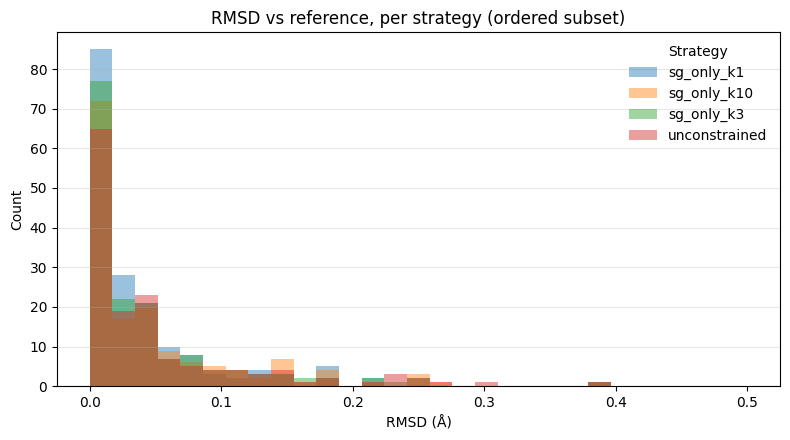

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0, max(0.5, rmsd_df.rmsd_angstrom.quantile(0.95)), 30)
for strategy, sub in rmsd_df.groupby('strategy'):
    ax.hist(sub.rmsd_angstrom, bins=bins, alpha=0.45, label=strategy)
ax.set_xlabel('RMSD (Å)')
ax.set_ylabel('Count')
ax.set_title('RMSD vs reference, per strategy (ordered subset)')
ax.legend(title='Strategy', frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. SG match by number of constituent elements

Higher-arity formulas are harder: the template pool gets sparser and the substitution engine has more role assignments to enumerate. The paper stratifies by `n_elements` using space-group match on the valid subset, which is what we plot here.

Two tables are printed below: SG match (%) per (n_elements, strategy) bin, and the corresponding valid-sample count per bin. Bins with very small n (e.g. n_elements = 7) are excluded from the bar chart because their percentages are dominated by sampling noise.

In [6]:
# Valid subset only — the same denominator used by the paper's Table 3.
valid = df[df['sub_success'] & df['relax_converged'] & (df['vol_change'] < 0.15)]

# SG match (%) per (n_elements, strategy)
sg_by_n = (valid.groupby(['n_elements', 'strategy'])['sg_match']
                .mean().mul(100).round(1)
                .unstack('strategy'))
# Valid sample count per (n_elements, strategy) — small n makes % noisy
n_by_n  = valid.groupby(['n_elements', 'strategy']).size().unstack('strategy').fillna(0).astype(int)

print('SG match on valid subset (%):')
print(sg_by_n)
print('\nValid sample count per bin:')
print(n_by_n)

SG match on valid subset (%):
strategy    sg_only_k1  sg_only_k10  sg_only_k3  unconstrained
n_elements                                                    
2                 46.5         15.7        29.2           18.5
3                 66.1         45.4        52.2           42.2
4                 60.4         48.9        51.6           43.6
5                 77.8         57.1        56.2           53.3
6                100.0         80.0        80.0           80.0
7                100.0        100.0       100.0          100.0

Valid sample count per bin:
strategy    sg_only_k1  sg_only_k10  sg_only_k3  unconstrained
n_elements                                                    
2                   43           51          48             54
3                  165          185         182            185
4                   91           94          95             94
5                   18           14          16             15
6                    4            5           5            

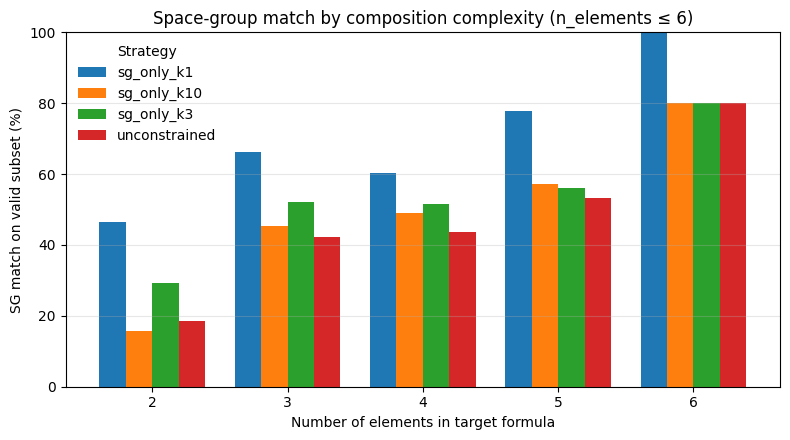

In [7]:
# Chart the bins that carry enough valid samples to be meaningful.
# The n=7 bin has only a handful of valid predictions (see n_by_n above)
# so its percentages are noisy — skip it in the bar chart.
by_n_plot = sg_by_n.loc[sg_by_n.index <= 6]

fig, ax = plt.subplots(figsize=(8, 4.5))
by_n_plot.plot(kind='bar', ax=ax, width=0.78)
ax.set_xlabel('Number of elements in target formula')
ax.set_ylabel('SG match on valid subset (%)')
ax.set_title('Space-group match by composition complexity (n_elements ≤ 6)')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Strategy', frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Volume change during relaxation

`vol_change = |V_relaxed − V_template| / V_template`. Values above the 15 % threshold are marked as filtered by the benchmark and excluded from the valid subset. A cluster of samples with very large ΔV/V usually indicates a template chemically too far from the target for MatterSim to relax cleanly.

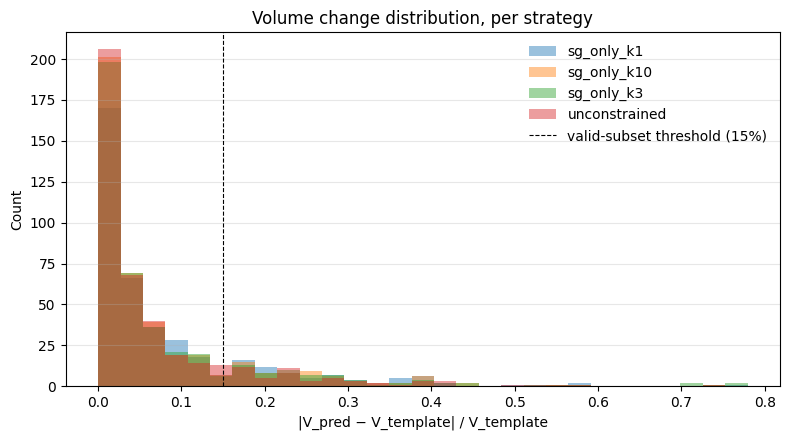

In [8]:
vol_df = df.dropna(subset=['vol_change'])
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0, vol_df.vol_change.quantile(0.99), 30)
for strategy, sub in vol_df.groupby('strategy'):
    ax.hist(sub.vol_change, bins=bins, alpha=0.45, label=strategy)
ax.axvline(0.15, color='k', ls='--', lw=0.8, label='valid-subset threshold (15%)')
ax.set_xlabel('|V_pred − V_template| / V_template')
ax.set_ylabel('Count')
ax.set_title('Volume change distribution, per strategy')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()